In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Convolution2D, MaxPooling2D, Dropout, Flatten, Dense
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import pandas as pd
import random
import ntpath

torch


In [2]:
data_dir = 'sim_data'
columns = ['rgb', 'mask', 'steering']
data = pd.read_csv(os.path.join(data_dir, 'driving_log.csv'), names=columns)
pd.set_option('display.max_colwidth', None)
data.head()

,rgb,mask,steering
0,rgb,mask,steering
1,sim_data/RGB\00000.png,sim_data/masks\00000.png,0.0
2,sim_data/RGB\00001.png,sim_data/masks\00001.png,0.0006948008667677641
3,sim_data/RGB\00002.png,sim_data/masks\00002.png,0.0006948008667677641
4,sim_data/RGB\00003.png,sim_data/masks\00003.png,0.0


In [3]:
def path_leaf(path):
    head, tail = ntpath.split(path)
    return tail
data['rgb'] = data['rgb'].apply(path_leaf)
data['mask'] = data['mask'].apply(path_leaf)

data.head()

,rgb,mask,steering
0,rgb,mask,steering
1,00000.png,00000.png,0.0
2,00001.png,00001.png,0.0006948008667677641
3,00002.png,00002.png,0.0006948008667677641
4,00003.png,00003.png,0.0


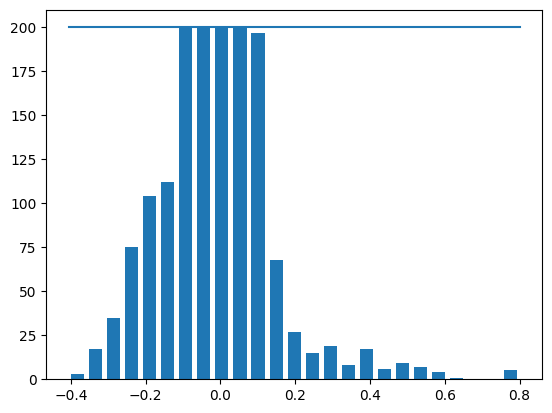

In [16]:
num_bins = 25
samples_per_bin = 200
hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
plt.bar(center, hist, width=0.035)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

length of data 1529
removed 0
remaining data 1529


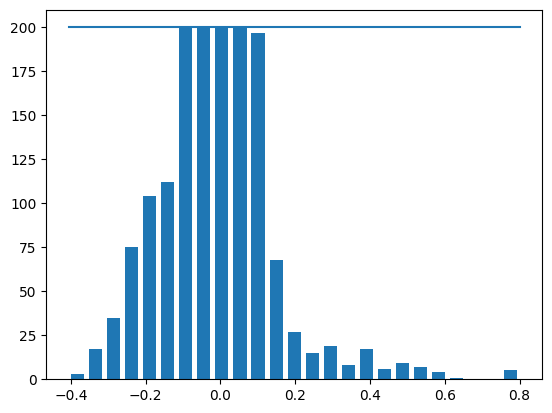

In [17]:
print(f"length of data {len(data)}")
remove_list = []

for j in range(num_bins):
    list_ = []
    for i in range(len(data['steering'])):
        if data['steering'].iloc[i] >= bins[j] and data['steering'].iloc[i] <= bins[j+1]:
            list_.append(i)
    list_ = shuffle(list_)
    list_ = list_[samples_per_bin:]
    remove_list.extend(list_)

print(f'removed {len(remove_list)}')
data.drop(data.index[remove_list], inplace=True)
print(f'remaining data {len(data)}')

hist, _ = np.histogram(data['steering'], (num_bins))
plt.bar(center, hist, width=0.035)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))